<a href="https://colab.research.google.com/github/DanyRE4020/Concentracion_IA_avanzada/blob/main/Notebook5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
# Se deben subir los archivos a /content de colab
data_2024 = pd.read_csv('/content/contaminantes_2024.csv', sep=',',skiprows=9,encoding="utf-8")
data_2025 = pd.read_csv('/content/contaminantes_2025.csv',sep=',', skiprows=9,encoding="utf-8")
data_2026 = pd.read_csv('/content/contaminantes_2026.csv', sep=',',skiprows=9,encoding="utf-8")
data_2024.columns = ["date", "id_station", "id_parameter", "value", "unit"]
data_2025.columns = ["date", "id_station", "id_parameter", "value", "unit"]
data_2026.columns = ["date", "id_station", "id_parameter", "value", "unit"]

In [34]:
# Concatenarlos en un solo df
data_raw = pd.concat(
    [data_2024, data_2025, data_2026],
    ignore_index=True
)

data_raw["date"] = pd.to_datetime(data_raw["date"], errors="coerce")
data_raw["value"] = pd.to_numeric(data_raw["value"], errors="coerce")

data_raw

,date,id_station,id_parameter,value,unit
0,2024-01-01 01:00:00,ACO,CO,NaN,15.0
1,2024-01-01 01:00:00,ACO,NO,NaN,1.0
2,2024-01-01 01:00:00,ACO,NO2,NaN,1.0
3,2024-01-01 01:00:00,ACO,NOX,NaN,1.0
4,2024-01-01 01:00:00,ACO,O3,NaN,1.0
...,...,...,...,...,...
5394148,2026-02-28 23:00:00,XAL,O3,NaN,1.0
5394149,2026-02-28 23:00:00,XAL,PM10,NaN,2.0
5394150,2026-02-28 23:00:00,XAL,PM2.5,NaN,2.0
5394151,2026-02-28 23:00:00,XAL,PMCO,NaN,2.0


In [35]:
data = data_raw.copy()

data["date"] = pd.to_datetime(data["date"], errors="coerce")
data["value"] = pd.to_numeric(data["value"], errors="coerce")
data["unit"] = pd.to_numeric(data["unit"], errors="coerce")
data["id_station"] = data["id_station"].astype("string").str.strip().str.upper()
data["id_parameter"] = data["id_parameter"].astype("string").str.strip().str.upper()

nulos_antes = data.isna().sum().rename("nulos_antes")
duplicados_antes = data.duplicated().sum()
negativos_antes = (data["value"] < 0).sum()

data = data.dropna(
    subset=["date", "id_station", "id_parameter", "value", "unit"]
)
data = data.drop_duplicates()
data = data[data["value"] >= 0].copy()

data["anio"] = data["date"].dt.year
data["mes"] = data["date"].dt.month
data["dia"] = data["date"].dt.day
data["fecha"] = data["date"].dt.date
data["hora"] = data["date"].dt.hour

data = data[
    ["date", "fecha", "anio", "mes", "dia", "hora",
     "id_station", "id_parameter", "value", "unit"]
].sort_values(["date", "id_station", "id_parameter"]).reset_index(drop=True)

reporte_limpieza = pd.DataFrame({
    "indicador": [
        "Filas originales",
        "Filas finales",
        "Filas eliminadas",
        "Duplicados detectados",
        "Valores negativos detectados"
    ],
    "resultado": [
        len(data_raw),
        len(data),
        len(data_raw) - len(data),
        duplicados_antes,
        negativos_antes
    ]
})

display(nulos_antes.to_frame())
display(reporte_limpieza)
display(data.head())


,nulos_antes
date,100828
id_station,0
id_parameter,0
value,2357916
unit,352512


,indicador,resultado
0,Filas originales,5394153
1,Filas finales,2809662
2,Filas eliminadas,2584491
3,Duplicados detectados,88601
4,Valores negativos detectados,1


,date,fecha,anio,mes,dia,hora,id_station,id_parameter,value,unit
0,2024-01-01 01:00:00,2024-01-01,2024,1,1,1,AJM,CO,0.23,15.0
1,2024-01-01 01:00:00,2024-01-01,2024,1,1,1,AJM,NO,0.00,1.0
2,2024-01-01 01:00:00,2024-01-01,2024,1,1,1,AJM,NO2,10.00,1.0
3,2024-01-01 01:00:00,2024-01-01,2024,1,1,1,AJM,NOX,10.00,1.0
4,2024-01-01 01:00:00,2024-01-01,2024,1,1,1,AJM,O3,43.00,1.0


In [36]:
print("Nulos después de la limpieza:")
display(data.isna().sum().to_frame("nulos"))

print(f"Duplicados después de la limpieza: {data.duplicated().sum():,}")
print(f"Años presentes en las fechas: {sorted(data['anio'].unique())}")
print(f"Parámetros disponibles: {sorted(data['id_parameter'].unique())}")


Nulos después de la limpieza:


,nulos
date,0
fecha,0
anio,0
mes,0
dia,0
hora,0
id_station,0
id_parameter,0
value,0
unit,0


Duplicados después de la limpieza: 0
Años presentes en las fechas: [np.int32(2024), np.int32(2025), np.int32(2026)]
Parámetros disponibles: ['CO', 'NO', 'NO2', 'NOX', 'O3', 'PM10', 'PM2.5', 'PMCO', 'SO2']


debemos saber si los tres periodos tienen la misma duración y cuántas estaciones aportan información. También si un contaminante no se esté comparando con distintas unidades.


In [37]:
cobertura = (
    data.groupby("anio")
    .agg(
        fecha_inicial=("date", "min"),
        fecha_final=("date", "max"),
        dias_observados=("fecha", "nunique"),
        estaciones=("id_station", "nunique"),
        contaminantes=("id_parameter", "nunique"),
        mediciones=("value", "size")
    )
    .reset_index()
)

unidades_por_contaminante = (
    data.groupby("id_parameter")["unit"]
    .agg(numero_unidades="nunique", unidades=lambda x: sorted(x.unique()))
    .reset_index()
)

display(cobertura)
display(unidades_por_contaminante)

if (unidades_por_contaminante["numero_unidades"] > 1).any():
    print("Advertencia: hay contaminantes con más de una unidad. Las estadísticas se separarán por unidad.")


,anio,fecha_inicial,fecha_final,dias_observados,estaciones,contaminantes,mediciones
0,2024,2024-01-01 01:00:00,2024-12-31 23:00:00,366,32,9,1347430
1,2025,2025-01-01 00:00:00,2025-12-31 23:00:00,365,33,9,1425789
2,2026,2026-02-18 00:00:00,2026-02-28 23:00:00,11,25,9,36443


,id_parameter,numero_unidades,unidades
0,CO,1,[15.0]
1,NO,1,[1.0]
2,NO2,1,[1.0]
3,NOX,1,[1.0]
4,O3,1,[1.0]
5,PM10,1,[2.0]
6,PM2.5,1,[2.0]
7,PMCO,1,[2.0]
8,SO2,1,[1.0]


In [38]:
columnas_grupo = ["anio", "id_parameter", "unit"]

resumen = (
    data.groupby(columnas_grupo)["value"]
    .agg(
        mediciones="count",
        media="mean",
        mediana="median",
        varianza="var",
        desviacion_estandar="std"
    )
    .reset_index()
)

modas = (
    data.groupby(columnas_grupo)["value"]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
    .reset_index(name="moda")
)

resumen = resumen.merge(
    modas,
    on=columnas_grupo,
    how="left"
)

resumen = resumen[
    [
        "anio",
        "id_parameter",
        "unit",
        "mediciones",
        "media",
        "mediana",
        "moda",
        "varianza",
        "desviacion_estandar"
    ]
]

resumen = resumen.sort_values(
    ["id_parameter", "anio"]
)

display(resumen.round(3))

,anio,id_parameter,unit,mediciones,media,mediana,moda,varianza,desviacion_estandar
0,2024,CO,15.0,176213,0.473,0.36,0.25,0.171,0.414
9,2025,CO,15.0,197279,0.524,0.44,0.30,0.145,0.381
18,2026,CO,15.0,4791,0.734,0.56,0.30,0.299,0.547
1,2024,NO,1.0,154386,13.757,3.00,1.00,830.663,28.821
10,2025,NO,1.0,166558,11.575,3.00,1.00,557.968,23.621
19,2026,NO,1.0,4307,21.290,4.00,1.00,1677.418,40.956
2,2024,NO2,1.0,175962,23.383,21.00,14.00,195.041,13.966
11,2025,NO2,1.0,190758,21.957,20.00,15.00,160.486,12.668
20,2026,NO2,1.0,4723,28.795,26.00,12.00,320.356,17.898
3,2024,NOX,1.0,154386,37.216,25.00,14.00,1417.297,37.647


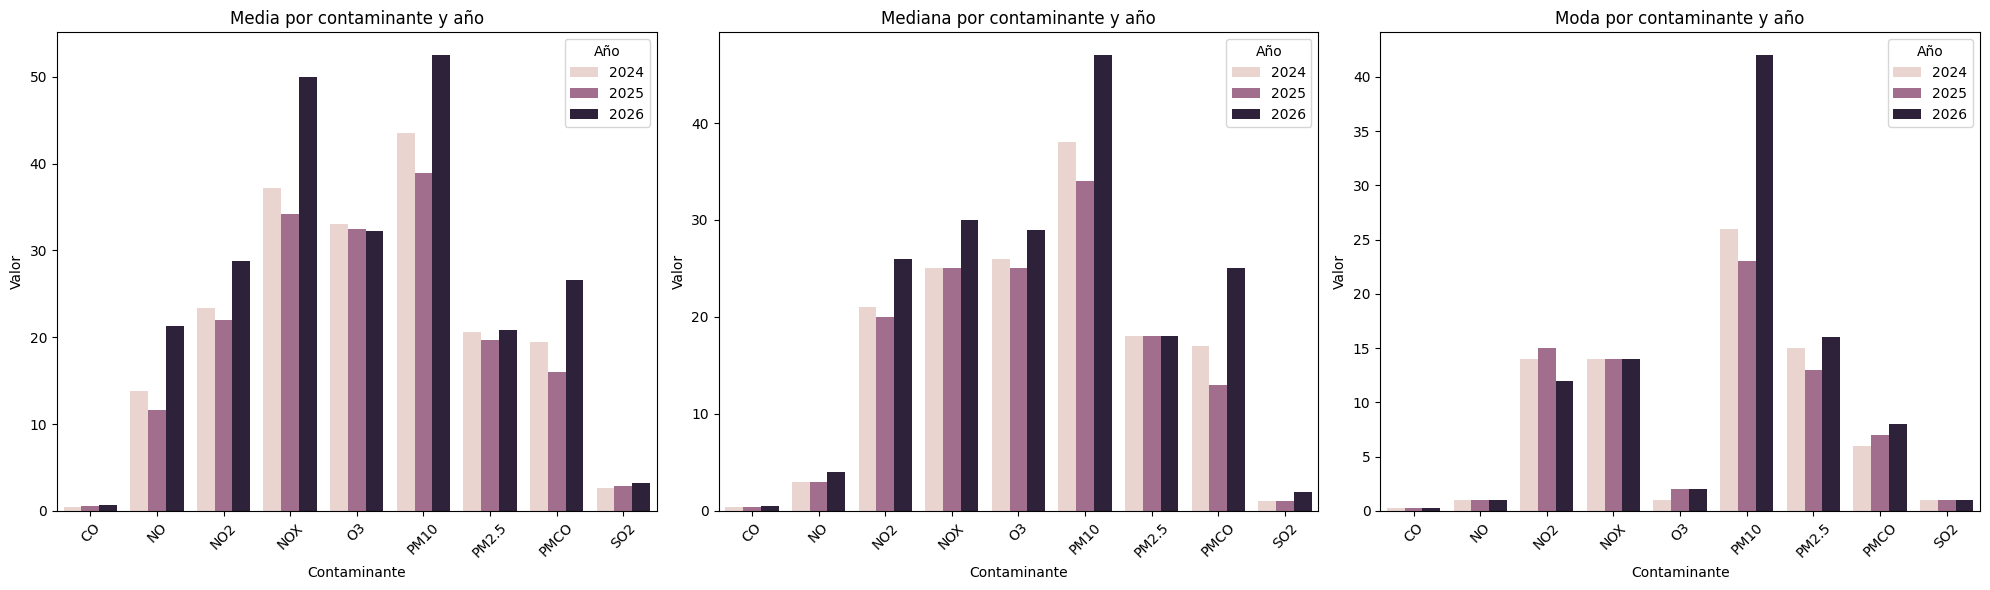

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.barplot(
    data=resumen,
    x="id_parameter",
    y="media",
    hue="anio",
    ax=axes[0]
)
axes[0].set_title("Media por contaminante y año")

sns.barplot(
    data=resumen,
    x="id_parameter",
    y="mediana",
    hue="anio",
    ax=axes[1]
)
axes[1].set_title("Mediana por contaminante y año")

sns.barplot(
    data=resumen,
    x="id_parameter",
    y="moda",
    hue="anio",
    ax=axes[2]
)
axes[2].set_title("Moda por contaminante y año")

for ax in axes:
    ax.set_xlabel("Contaminante")
    ax.set_ylabel("Valor")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(title="Año")

plt.tight_layout()
plt.show()

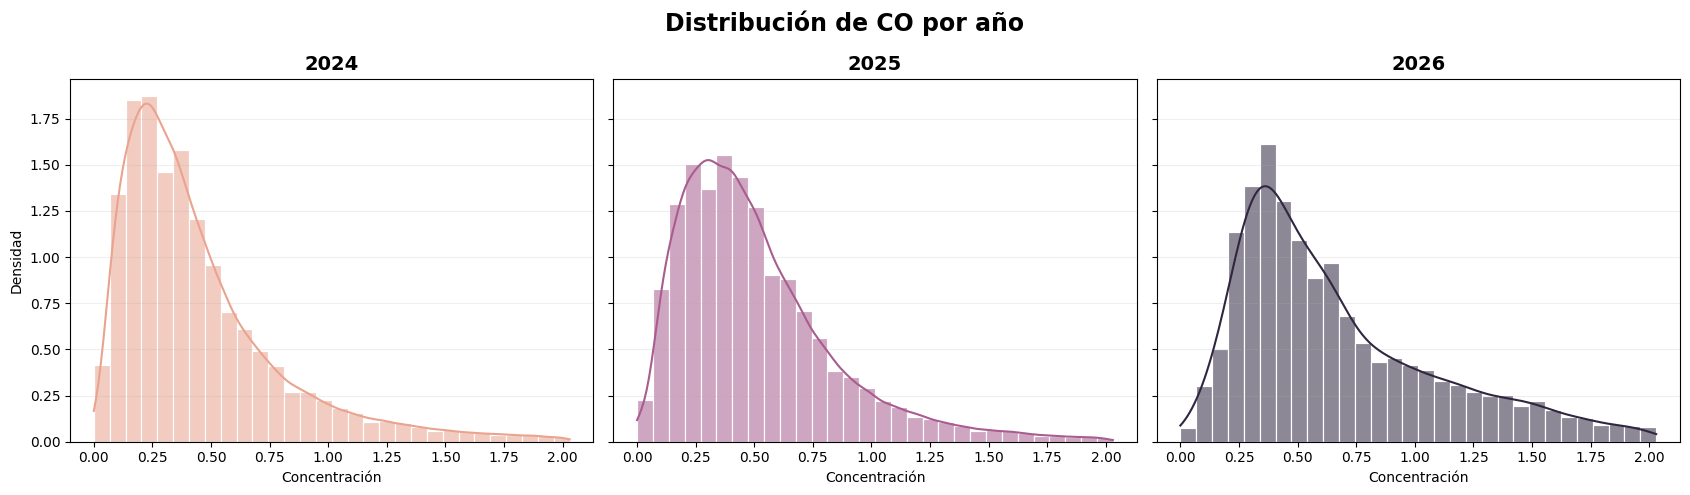

In [40]:
contaminante_elegido = "CO"

datos_distribucion = data[
    data["id_parameter"] == contaminante_elegido
].copy()

limite_superior = datos_distribucion["value"].quantile(0.99)

datos_distribucion = datos_distribucion[
    datos_distribucion["value"] <= limite_superior
]

anios = sorted(datos_distribucion["anio"].unique())

colores = {
    2024: "#E9A38F",
    2025: "#A85D8E",
    2026: "#302640"
}

fig, axes = plt.subplots(
    1,
    len(anios),
    figsize=(17, 5),
    sharex=True,
    sharey=True
)

for ax, anio in zip(axes, anios):

    datos_anio = datos_distribucion[
        datos_distribucion["anio"] == anio
    ]

    sns.histplot(
        data=datos_anio,
        x="value",
        bins=30,
        stat="density",
        kde=True,
        color=colores[anio],
        alpha=0.55,
        edgecolor="white",
        ax=ax
    )

    ax.set_title(
        str(anio),
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlabel("Concentración")
    ax.set_ylabel("Densidad")
    ax.grid(axis="y", alpha=0.2)

plt.suptitle(
    f"Distribución de {contaminante_elegido} por año",
    fontsize=17,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

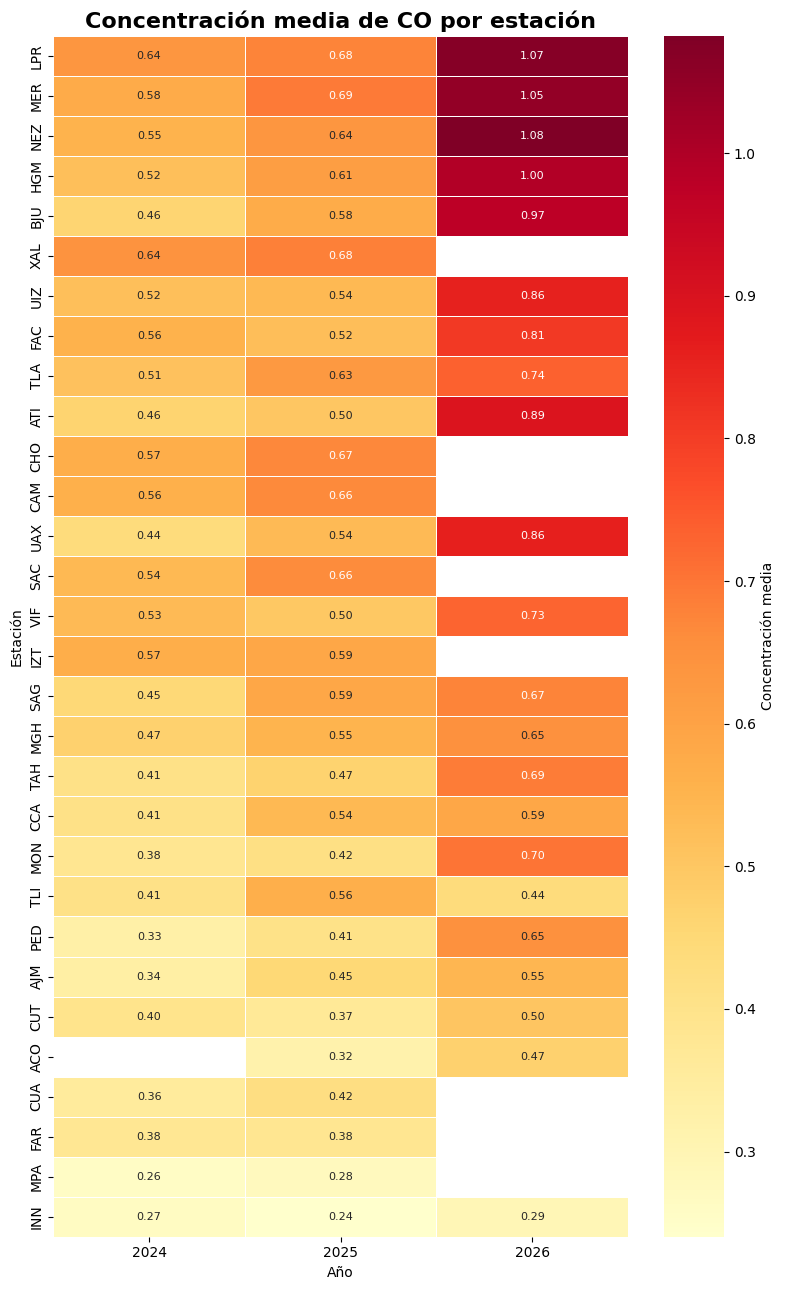

In [41]:
contaminante_elegido = "CO"

datos_estacion = data[
    data["id_parameter"] == contaminante_elegido
]

media_estacion = (
    datos_estacion.groupby(
        ["id_station", "anio"]
    )["value"]
    .mean()
    .unstack()
)

orden_estaciones = (
    media_estacion.mean(axis=1)
    .sort_values(ascending=False)
    .index
)

media_estacion = media_estacion.reindex(
    orden_estaciones
)

plt.figure(figsize=(8, 13))

sns.heatmap(
    media_estacion,
    cmap="YlOrRd",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    annot_kws={"size": 8},
    cbar_kws={"label": "Concentración media"}
)

plt.title(
    f"Concentración media de {contaminante_elegido} por estación",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Año")
plt.ylabel("Estación")
plt.tight_layout()
plt.show()

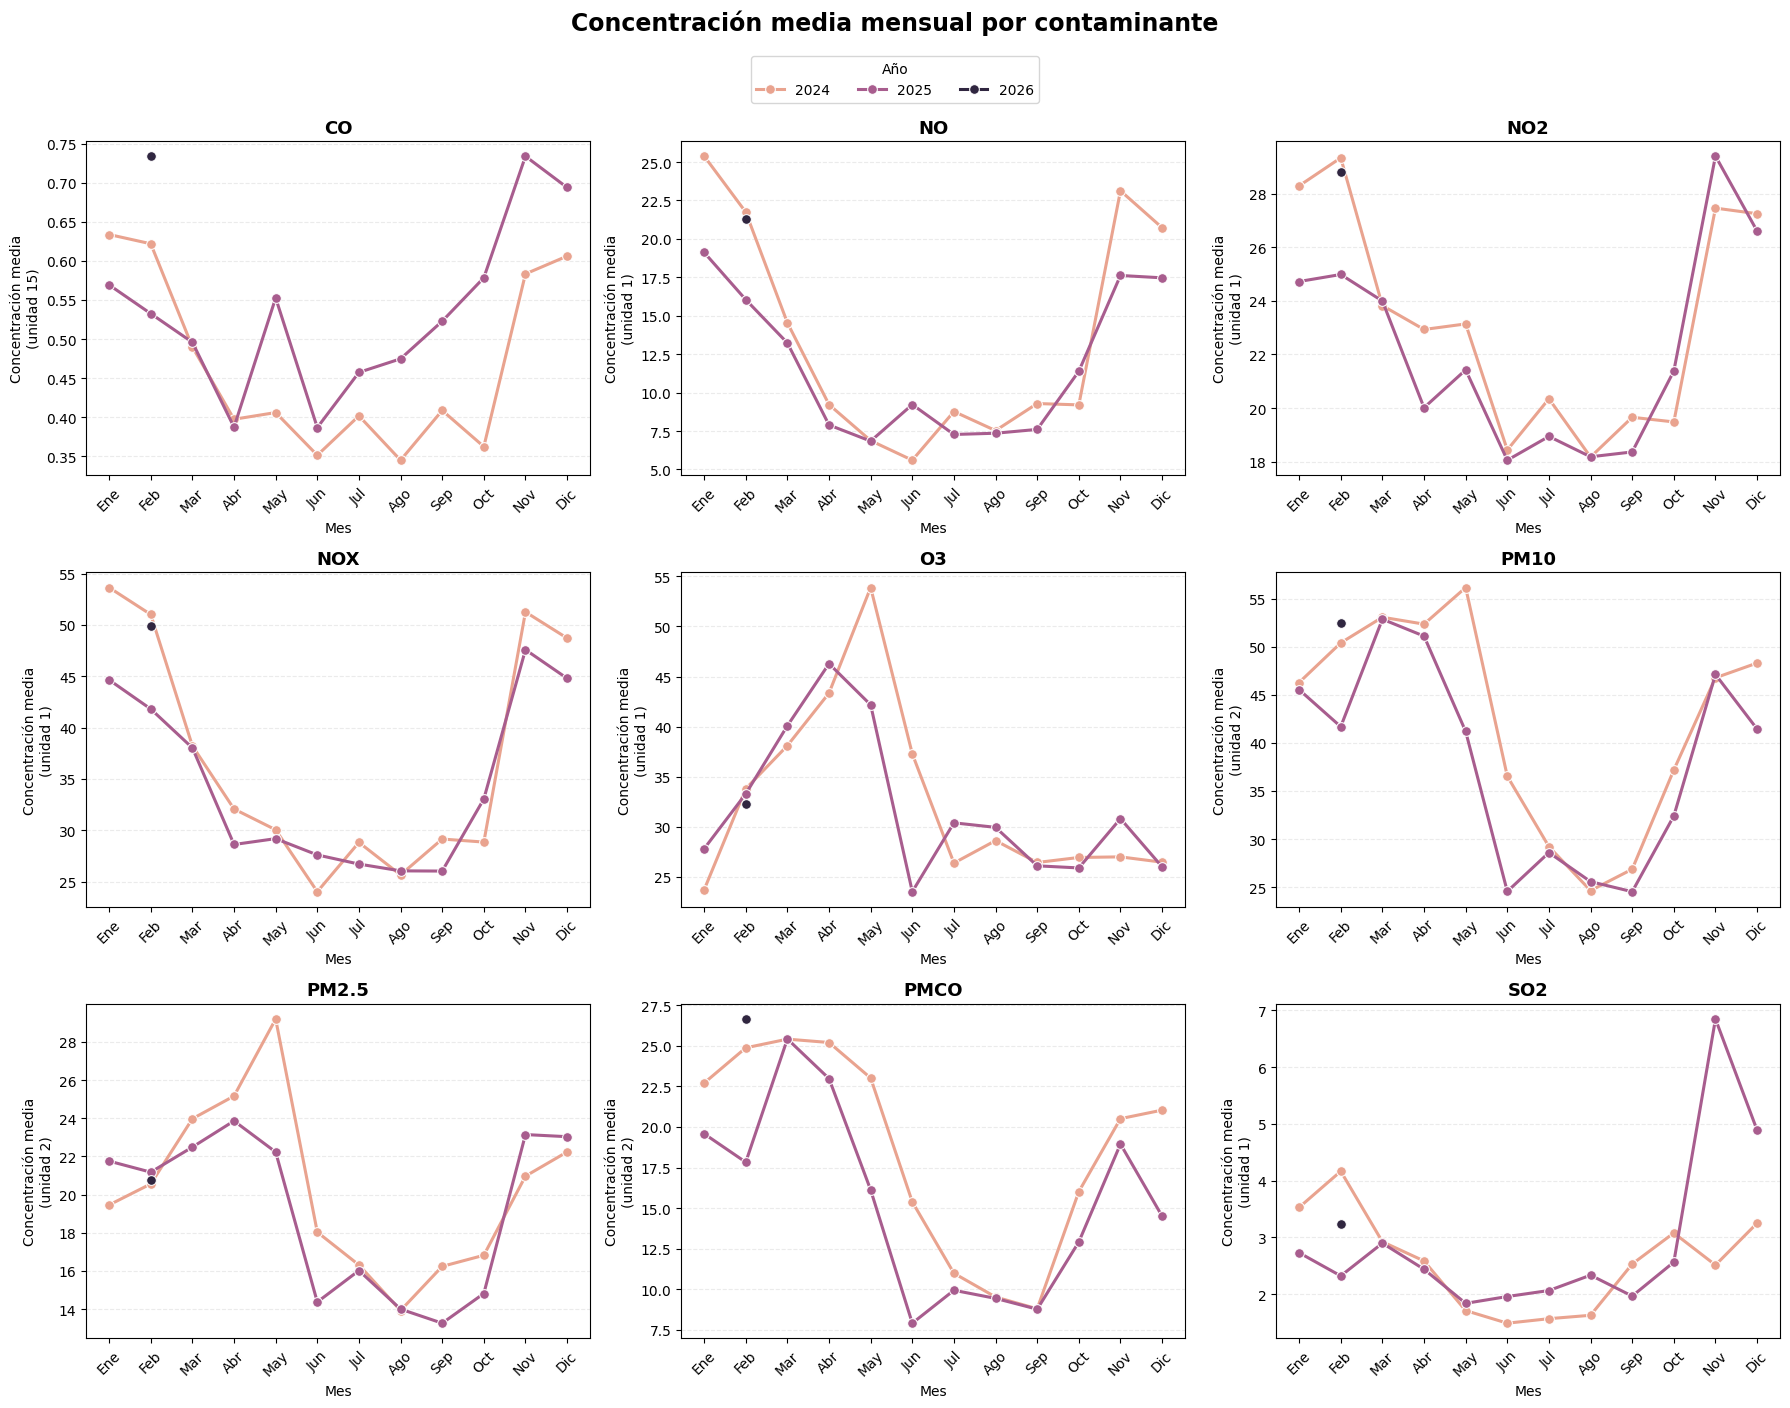

In [43]:

# 2026 es un periodo parcial
promedio_mensual = (
    data.groupby(
        ["anio", "mes", "id_parameter", "unit"],
        as_index=False
    )["value"]
    .mean()
)

contaminantes = sorted(
    promedio_mensual["id_parameter"].unique()
)

columnas = 3
filas = int(np.ceil(len(contaminantes) / columnas))

meses = [
    "Ene", "Feb", "Mar", "Abr",
    "May", "Jun", "Jul", "Ago",
    "Sep", "Oct", "Nov", "Dic"
]

colores = {
    2024: "#E9A38F",
    2025: "#A85D8E",
    2026: "#302640"
}

fig, axes = plt.subplots(
    filas,
    columnas,
    figsize=(18, 4.5 * filas)
)

axes = np.array(axes).reshape(-1)

for ax, contaminante in zip(axes, contaminantes):

    temporal = promedio_mensual[
        promedio_mensual["id_parameter"] == contaminante
    ]

    sns.lineplot(
        data=temporal,
        x="mes",
        y="value",
        hue="anio",
        palette=colores,
        marker="o",
        markersize=7,
        linewidth=2.2,
        ax=ax
    )

    unidad = temporal["unit"].mode().iloc[0]

    ax.set_title(
        contaminante,
        fontsize=13,
        fontweight="bold"
    )

    ax.set_xlabel("Mes")
    ax.set_ylabel(f"Concentración media\n(unidad {unidad:g})")

    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(meses, rotation=45)

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.25
    )

handles, labels = axes[0].get_legend_handles_labels()

for ax in axes:
    if ax.get_legend() is not None:
        ax.get_legend().remove()

for ax in axes[len(contaminantes):]:
    ax.remove()

fig.legend(
    handles,
    labels,
    title="Año",
    loc="upper center",
    ncol=3,
    bbox_to_anchor=(0.5, 1.01)
)

plt.suptitle(
    "Concentración media mensual por contaminante",
    fontsize=17,
    fontweight="bold",
    y=1.04
)

plt.tight_layout()
plt.show()

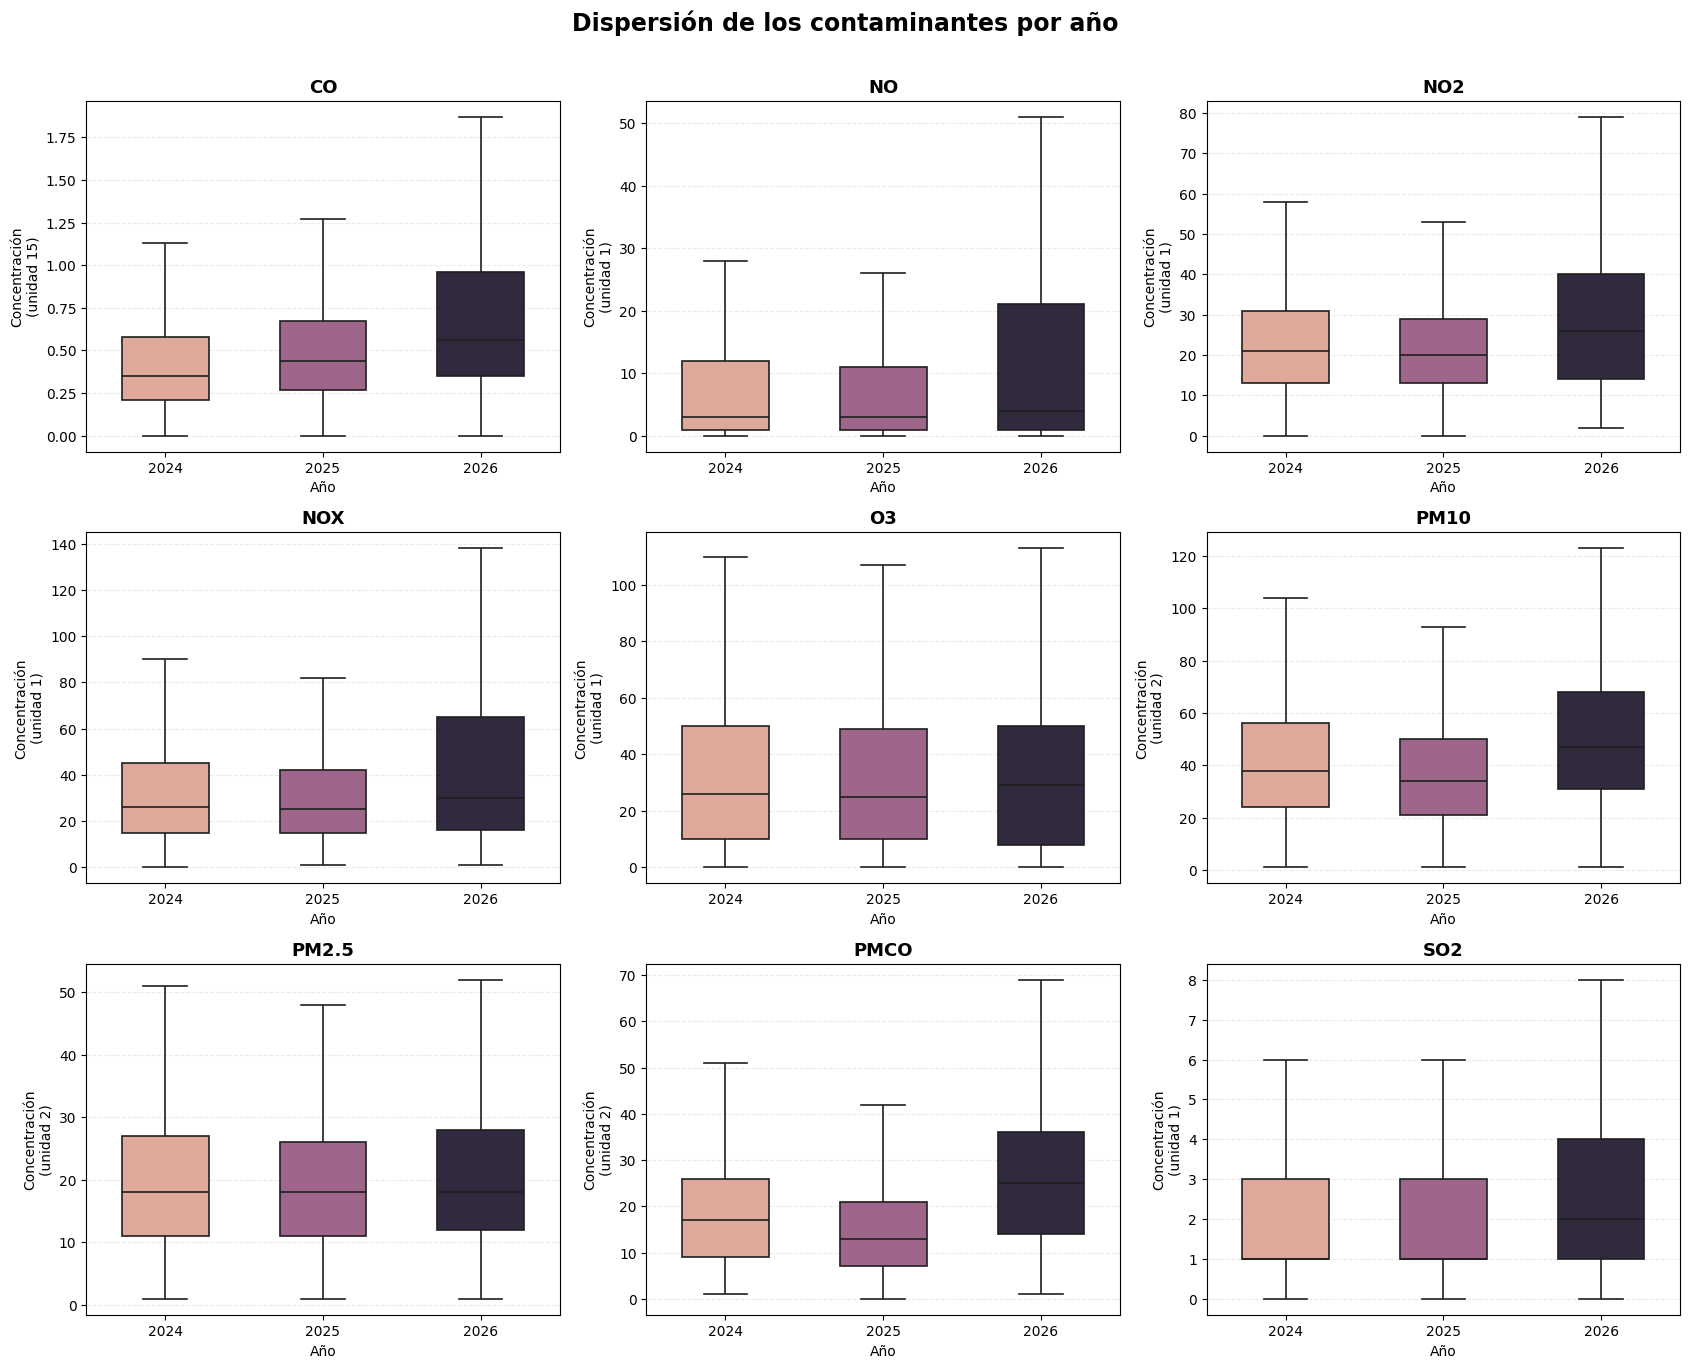

In [45]:
partes_boxplot = []

for (anio, contaminante), grupo in data.groupby(
    ["anio", "id_parameter"]
):

    muestra_grupo = grupo.sample(
        n=min(len(grupo), 20000),
        random_state=42
    )

    partes_boxplot.append(muestra_grupo)

muestra_boxplot = pd.concat(
    partes_boxplot,
    ignore_index=True
)

contaminantes_boxplot = sorted(
    muestra_boxplot["id_parameter"].unique()
)

anios_boxplot = sorted(
    muestra_boxplot["anio"].unique()
)

columnas = 3
filas = int(
    np.ceil(len(contaminantes_boxplot) / columnas)
)

colores = {
    2024: "#E9A38F",
    2025: "#A85D8E",
    2026: "#302640"
}

fig, axes = plt.subplots(
    filas,
    columnas,
    figsize=(17, 4.5 * filas)
)

axes = np.array(axes).reshape(-1)

for ax, contaminante in zip(
    axes,
    contaminantes_boxplot
):

    temporal = muestra_boxplot[
        muestra_boxplot["id_parameter"] == contaminante
    ]

    sns.boxplot(
        data=temporal,
        x="anio",
        y="value",
        hue="anio",
        order=anios_boxplot,
        palette=colores,
        showfliers=False,
        width=0.55,
        linewidth=1.2,
        legend=False,
        ax=ax
    )

    unidad = temporal["unit"].mode().iloc[0]

    ax.set_title(
        contaminante,
        fontsize=13,
        fontweight="bold"
    )

    ax.set_xlabel("Año")
    ax.set_ylabel(
        f"Concentración\n(unidad {unidad:g})"
    )

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.25
    )

for ax in axes[len(contaminantes_boxplot):]:
    ax.remove()

plt.suptitle(
    "Dispersión de los contaminantes por año",
    fontsize=17,
    fontweight="bold",
    y=1.01
)

plt.tight_layout()
plt.show()